# Melbourne Weather Code Workflow

## Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
melb = pd.read_csv("Melbourne01.csv",low_memory=False,on_bad_lines="skip")


In [4]:
melb.columns

Index(['2011', ' 1', ' 1.1', ' 0', ' 4', ' 24.8', ' 0.0', ' 14.0', ' 51',
       ' SE', ' 11', ' 13', ' 1007.4', ' 0.0.1'],
      dtype='object')

In [5]:
melb.columns = ['Year', 'Month', 'Day', 'Hour', 'Min', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)']

In [6]:
melb.drop_duplicates().reset_index(drop=True)

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575950,2025,03,12.0,15.0,30.0,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0
575951,2025,03,12.0,15.0,34.0,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0
575952,2025,03,12.0,16.0,0.0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0
575953,2025,03,12.0,16.0,30.0,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0


In [7]:
melb_str = melb[melb["Month"].map(type) == str]

In [8]:
melb_str["Month"].unique()

array([' 1', ' 2', ' 3', ' 4', ' 5', ' 6', ' 7', ' 8', ' 9', ' 10', ' 11',
       ' 12', ' 1\t18\t11\t00\t18.8\t15.9\t9.6\t55\tS\t32\t43\t1014.8\t0',
       ' 1\t18\t11\t30\t20\t16.8\t10.1\t53\tS\t28\t43\t1015.1\t0',
       ' 1\t18\t12\t00\t19\t14.8\t11.1\t60\tS\t32\t43\t1015.4\t0',
       ' 1\t18\t12\t30\t19.2\t14.9\t9.4\t53\tSSE\t35\t48\t1015.6\t0',
       ' 1\t18\t13\t00\t19.4\t15.9\t8.7\t50\tS\t30\t44\t1015.9\t0',
       ' 1\t18\t13\t30\t19.5\t15.9\t8.5\t49\tS\t33\t50\t1016.2\t0',
       ' 1\t18\t14\t00\t19.3\t15.3\t8.3\t49\tSSE\t33\t46\t1016\t0',
       ' 1\t18\t14\t30\t19.3\t15.8\t8.9\t51\tS\t33\t50\t1015.9\t0',
       ' 1\t18\t15\t00\t19.4\t15.3\t8.7\t50\tS\t35\t48\t1015.6\t0',
       ' 1\t18\t15\t30\t19.2\t14.7\t7\t45\tS\t32\t46\t1015.6\t0',
       ' 1\t18\t16\t00\t19.3\t15.8\t7.1\t45\tS\t35\t50\t1015.8\t0',
       ' 1\t18\t16\t30\t19.5\t16.3\t10\t54\tS\t32\t48\t1015.8\t0',
       ' 1\t18\t17\t00\t19\t15\t8.9\t52\tSSE\t33\t41\t1015.8\t0',
       ' 1\t18\t17\t30\t18.6\t14.6\t8.3

In [9]:
tabbed_months = melb_str["Month"].unique()[12:28]

In [10]:
n_position = 580364
for month in tabbed_months:
    month = month.split("\t")
    empty_first = [""] + month
    row = pd.Series(empty_first)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row= row.to_list()
    melb.loc[n_position] = row
    melb.iloc[n_position,0] = 2017
    n_position +=1
    

/tmp/ipykernel_139/149201672.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_139/149201672.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_139/149201672.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_139/149201672.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future 

In [11]:
fix_year = melb[melb['Month'].isna()].loc[::,"Year"]
indices = melb[melb['Month'].isna()].index.to_list()

In [12]:
y_position = 0
for year in fix_year:
    year = year.strip()
    year = year.split("\t")
    # row = pd.to_numeric(pd.Series(year), errors = 'ignore').to_list()

    row = pd.Series(year)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row=row.to_list()
    
    y_ind = indices[y_position]
    melb.loc[y_ind] = row
    y_position +=1

In [13]:
melb[melb['Month'].isna()]

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm)


In [14]:
melb["Day"] = melb["Day"].astype(int)

In [15]:
melb["Year"].value_counts()

Year
2015    120194
2016     93673
2020     93365
2017     93184
2018     93156
2014     93155
2019     93112
2013     90510
2011     89961
2012     88409
2022     66410
2021     53589
2024     21509
2023     17818
2025      5090
2017        16
Name: count, dtype: int64

In [16]:
melb["Year"] = melb["Year"].astype(int)

In [17]:
melb["Year"].value_counts()

Year
2015    120194
2016     93673
2020     93365
2017     93200
2018     93156
2014     93155
2019     93112
2013     90510
2011     89961
2012     88409
2022     66410
2021     53589
2024     21509
2023     17818
2025      5090
Name: count, dtype: int64

In [18]:
replace_month = {' 1': 1,
                 ' 2': 2,
                 ' 3': 3,
                 ' 4': 4,
                 ' 5': 5,
                 ' 6': 6,
                 ' 7': 7,
                 ' 8': 8,
                 ' 9': 9,
                 ' 10': 10,
                 ' 11': 11,
                 ' 12': 12,
                 ' 06': 6,
                 ' 03': 3,
                 ' 04': 4,
                 ' 05': 5,
                 ' 07': 7,
                 ' 08': 8,
                 ' 09': 9,
                 ' 01': 1,
                 ' 02': 2,
                 '09': 9,
                 '05': 5,
                 '02': 2,
                 '08': 8,
                 '1': 1,
                 '6': 6,
                 '8': 8,
                 '7': 7,
                 '5': 5,
                 '11':11
                }

In [19]:
melb["Month"] = melb["Month"].replace(replace_month)

/tmp/ipykernel_139/984582946.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  melb["Month"] = melb["Month"].replace(replace_month)


In [20]:
replace_hour = {'06': 6,
                 '03': 3,
                 '04': 4,
                 '05': 5,
                 '07': 7,
                 '08': 8,
                 '09': 9,
                 '01': 1,
                 '02': 2,
                '00': 0
                }

In [21]:
melb["Hour"] = melb["Hour"].replace(replace_hour)
melb["Hour"] = melb["Hour"].astype(int)

In [22]:
melb['Min'] = melb['Min'].astype(int)

In [23]:
melb["Air Temp (degrees C)"] = melb["Air Temp (degrees C)"].astype(float)

In [24]:
melb["Apparent Temp (degrees C)"] = melb["Apparent Temp (degrees C)"].astype(float)

In [25]:
melb["Dew Pt Temp (degrees C)"] = melb["Dew Pt Temp (degrees C)"].astype(float)

In [26]:
melb['Humidity (%)'] = melb['Humidity (%)'].astype(int)

In [27]:
melb['Wind Gust  (km/h)'] = melb['Wind Gust  (km/h)'].astype(int)

In [28]:
melb['Wind Speed (km/h)'] = melb['Wind Speed (km/h)'].astype(int)

In [29]:
melb['MSLP (hPa)'] = melb['MSLP (hPa)'].astype(float)

In [30]:
melb['Rainfall since 9 am (mm)'] = melb['Rainfall since 9 am (mm)'].str.strip()
melb['Rainfall since 9 am (mm)'] = pd.to_numeric(melb['Rainfall since 9 am (mm)'], errors = 'coerce')

In [31]:
melb = melb.rename(columns={'Min': 'Minute'})

In [32]:
melb["Datetime"] = pd.to_datetime(melb[["Year","Month", "Hour", "Day", "Minute"]], errors = 'coerce')

In [33]:
with pd.option_context("display.max_rows",None):
    print(melb["Wind Direction"].value_counts())

Wind Direction
 N         276369
 S         136085
 W          87480
 WSW        81667
 SW         80151
 SSW        76062
 SSE        71341
 NNE        65602
 WNW        55938
 NNW        55817
 NW         40438
 SE         26632
 CALM       19598
 NE         15075
 ESE         8582
 E           7827
 ENE         7791
N             205
SW             75
S              62
SSW            60
W              43
WSW            39
WNW            30
NNE            27
NNW            20
CALM           17
NW             17
SSE            15
SE              8
 -              6
NE              5
ENE             5
 1016.6         4
 1015.9         3
 1017.0         2
ESE             2
E               2
 1017.4         2
 1016.1         2
 1014.6         2
 1015.6         2
 1020.4         2
 1019.5         2
 1021.0         2
 1022.7         1
 1004.5         1
 1022.3         1
 1016.9         1
 1008.2         1
 1019.0         1
 1010.3         1
 1010.8         1
 1024.2         1
 1029.6      

In [34]:
melb["Wind Direction"].unique()

array([' SE', ' ESE', ' NE', ' NNE', ' ENE', ' W', ' N', ' SW', ' SSE',
       ' S', ' SSW', ' WSW', ' NW', ' WNW', ' NNW', ' E', ' CALM',
       ' 1016.6', ' 1016.9', ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1',
       ' 1025.3', ' 1024.2', ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0',
       'ENE', 'NE', 'N', 'NNE', 'NNW', 'NW', 'SSW', 'SW', 'WSW', 'W',
       'WNW', ' 1015.5', 'S', 'SE', 'SSE', 'ESE', 'CALM', 'E', ' 1014.2',
       ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0', ' 1013.6',
       ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6', ' 1015.8',
       ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5', ' 1019.8',
       ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7', ' 1021.9',
       ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3', ' 1012.0',
       ' 1010.8', ' -'], dtype=object)

In [35]:
replace_direction = {' SE': 'SE',
                     ' ESE': 'ESE',
                     ' NE': 'NE',
                     ' NNE': 'NNE',
                     ' ENE': 'ENE',
                     ' W': 'W',
                     ' N': 'N',
                     ' SW': 'SW',
                     ' SSE': 'SSE',
                     ' S': 'S',
                     ' SSW': 'SSW',
                     ' WSW': 'WSW',
                     ' NW': 'NW',
                     ' WNW': 'WNW',
                     ' NNW': 'NNW',
                     ' E': 'E',
                     ' CALM': 'STILL',
                     'CALM': 'STILL',
                    ' -': "STILL"}


In [36]:
melb["Wind Direction"] = melb["Wind Direction"].replace(replace_direction)

In [37]:
melb["Wind Direction"].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'STILL', ' 1016.6', ' 1016.9',
       ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1', ' 1025.3', ' 1024.2',
       ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0', ' 1015.5', ' 1014.2',
       ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0', ' 1013.6',
       ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6', ' 1015.8',
       ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5', ' 1019.8',
       ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7', ' 1021.9',
       ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3', ' 1012.0',
       ' 1010.8'], dtype=object)

In [38]:
melb["Wind Direction"].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'STILL', ' 1016.6', ' 1016.9',
       ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1', ' 1025.3', ' 1024.2',
       ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0', ' 1015.5', ' 1014.2',
       ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0', ' 1013.6',
       ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6', ' 1015.8',
       ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5', ' 1019.8',
       ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7', ' 1021.9',
       ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3', ' 1012.0',
       ' 1010.8'], dtype=object)

In [39]:
# pd.set_option('display.max_rows', 20)

In [40]:
directions = melb["Wind Direction"].unique()

In [41]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,0.0,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,0.0,0.0,2016-02-07 09:00:00


In [42]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,0.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,0.0,0.0,2012-09-24 14:34:00


In [43]:
di_i = 0
for di in directions:
    
    fixed = di.strip()
    try:
        fixed = float(fixed)
    except (ValueError,TypeError):
        pass
    if isinstance(fixed,float):
        indx_list = melb.index[melb["Wind Direction"] == di].to_list()
        for i in indx_list:
            melb.loc[i,"MSLP (hPa)"] = fixed
    
            

In [44]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,1016.6,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,1016.6,0.0,2016-02-07 09:00:00


In [45]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,1017.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,1017.0,0.0,2012-09-24 14:34:00


In [46]:
melb.columns

Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Datetime'],
      dtype='object')

In [47]:
for i in range(melb.shape[0]):
    if melb.loc[i, "Wind Speed (km/h)"] == 0 and melb.loc[i, "Wind Direction"] != "STILL":
        melb.loc[i, "Wind Direction"] = "STILL"
        
    if melb.loc[i, "Wind Direction"] == "STILL" and melb.loc[i, "Wind Speed (km/h)"] > 0.0:
        melb.loc[i, "Wind Direction"] = None
        
    if melb.loc[i, "Wind Speed (km/h)"] <0:
        melb.loc[i, "Wind Direction"] = None
        melb.loc[i, "Wind Speed (km/h)"] = None

    if melb.loc[i, "Wind Gust  (km/h)"] <0:
        melb.loc[i, "Wind Gust  (km/h)"] = None
        # melb.loc[i, "Wind Speed (km/h)"] = None
        

In [48]:
with pd.option_context('display.max_rows', None):
    print(melb["Wind Speed (km/h)"].value_counts())

Wind Speed (km/h)
13.0     93443
15.0     92110
11.0     90386
17.0     89537
9.0      83570
19.0     77005
20.0     61226
7.0      60520
22.0     54449
24.0     52009
26.0     50239
28.0     47251
30.0     39606
32.0     32826
0.0      31952
33.0     26615
35.0     21726
6.0      19908
37.0     17014
39.0     13219
41.0     10467
43.0      8221
44.0      6604
4.0       5885
46.0      5341
48.0      4428
2.0       3783
50.0      3630
52.0      2808
54.0      2171
56.0      1529
57.0      1120
59.0       752
61.0       540
63.0       381
65.0       281
67.0       181
69.0       137
70.0        76
72.0        58
74.0        41
76.0        34
80.0        20
78.0        15
83.0        10
82.0         6
85.0         6
87.0         3
89.0         2
100.0        2
1.0          1
3.0          1
Name: count, dtype: int64


In [49]:
# When there is a positive wind speed and wind direction is "STILL", I will change the wind direction to an "NaN"

# When there is a wind speed of 0, and a classified wind direction, I will change the wind direction to "STILL".

# done!

In [50]:
melb[melb["Wind Speed (km/h)"] <0]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime


In [51]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime


In [52]:
melb[melb["Wind Direction"] == ' 1010.3'].index


Index([657481], dtype='int64')

In [53]:
# melb[melb["Wind Direction"] == ' 1012.0'].index

melb.loc[657500, "Wind Direction"] = None
melb.loc[657481, "Wind Direction"] = None
melb.loc[657500, "Wind Speed (km/h)"] = None

melb.loc[657481, "Wind Speed (km/h)"] = None

In [54]:
melb[melb["Apparent Temp (degrees C)"] == 0]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059055,2022,8,9,5,10,3.3,0.0,2.4,94,N,13.0,13.0,1027.0,0.0,2022-08-09 05:10:00
1059056,2022,8,9,5,10,3.3,0.0,2.4,94,N,13.0,13.0,1027.0,0.0,2022-08-09 05:10:00
1060262,2022,8,14,3,10,8.5,0.0,8.6,100,WNW,17.0,19.0,1008.9,0.0,2022-08-14 03:10:00
1060263,2022,8,14,3,10,8.5,0.0,8.6,100,WNW,17.0,19.0,1008.9,0.0,2022-08-14 03:10:00


A lot of 

In [55]:
melb["Wind Direction"].value_counts()

Wind Direction
N        271169
S        135475
W         86648
WSW       81096
SW        79415
SSW       75415
SSE       70956
NNE       65203
WNW       55112
NNW       55106
NW        39759
STILL     31952
SE        26464
NE        14711
ESE        8437
E          7612
ENE        7596
Name: count, dtype: int64

In [56]:
melb["Wind Gust  (km/h)"].value_counts()

Wind Gust  (km/h)
15.0     79669
13.0     79551
17.0     77571
11.0     77352
19.0     75941
9.0      67899
26.0     61831
28.0     55486
20.0     51679
30.0     48184
24.0     44093
22.0     43650
32.0     42364
7.0      42108
33.0     36209
0.0      32282
35.0     31315
37.0     26917
39.0     22505
41.0     18740
48.0     11226
43.0     10934
6.0      10207
44.0      9776
50.0      9303
46.0      8878
52.0      7502
54.0      5899
56.0      4862
57.0      4041
59.0      3049
61.0      2527
63.0      1886
4.0       1441
65.0       984
67.0       888
69.0       885
70.0       779
72.0       640
74.0       502
76.0       362
2.0        350
78.0       266
80.0       174
82.0       135
83.0        79
89.0        49
87.0        33
85.0        32
91.0        27
93.0        24
96.0        16
95.0        15
98.0         8
104.0        5
102.0        4
100.0        4
109.0        2
Name: count, dtype: int64

In [57]:
melb[melb["MSLP (hPa)"] <0]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
969173,2021,5,30,10,0,5.7,2.5,3.2,84,WNW,6.0,9.0,-9999.0,0.0,2021-05-30 10:00:00
969174,2021,5,30,10,30,8.2,5.9,4.8,79,NNE,4.0,9.0,-9999.0,0.0,2021-05-30 10:30:00
969175,2021,5,30,11,0,10.3,8.8,5.1,70,SE,4.0,9.0,-9999.0,0.0,2021-05-30 11:00:00
969176,2021,5,30,11,30,11.5,10.0,5.2,65,SE,2.0,9.0,-9999.0,0.0,2021-05-30 11:30:00
969177,2021,5,30,12,0,11.4,9.4,4.2,61,ENE,2.0,7.0,-9999.0,0.0,2021-05-30 12:00:00
969178,2021,5,30,12,30,12.4,11.1,4.1,57,ENE,6.0,11.0,-9999.0,0.0,2021-05-30 12:30:00
969179,2021,5,30,13,0,12.1,10.0,3.9,57,SE,9.0,11.0,-9999.0,0.0,2021-05-30 13:00:00
969180,2021,5,30,13,30,12.7,10.4,4.7,58,ESE,9.0,13.0,-9999.0,0.0,2021-05-30 13:30:00
969181,2021,5,30,14,0,13.0,10.4,4.2,55,SSE,7.0,11.0,-9999.0,0.0,2021-05-30 14:00:00
969182,2021,5,30,14,30,13.1,11.3,3.7,53,ESE,4.0,11.0,-9999.0,0.0,2021-05-30 14:30:00


In [58]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(melb.describe())

            Year      Month        Day       Hour     Minute  \
count 1113151.00 1113151.00 1113151.00 1113151.00 1113151.00   
mean     2016.50       6.45      15.76      11.44      26.12   
min      2011.00       1.00       1.00       0.00       0.00   
25%      2014.00       3.00       8.00       5.00      10.00   
50%      2016.00       6.00      16.00      11.00      30.00   
75%      2019.00       9.00      23.00      17.00      40.00   
max      2025.00      12.00      31.00      23.00      59.00   
std         3.53       3.44       8.81       6.89      17.24   

       Air Temp (degrees C)  Apparent Temp (degrees C)  \
count            1113151.00                 1113151.00   
mean                  15.78                      12.05   
min                    0.50                   -9999.00   
25%                   11.80                       7.60   
50%                   15.10                      11.70   
75%                   18.90                      16.50   
max              

In [59]:
melb.loc[melb["MSLP (hPa)"] <0, "MSLP (hPa)"] = None

In [60]:
melb2 = melb.loc[:200]

In [61]:
melb2

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,2011,1,1,18,44,19.8,0.0,11.7,59,S,19.0,20.0,1013.8,0.0,2011-01-01 18:44:00
197,2011,1,1,18,54,19.6,0.0,11.6,60,S,26.0,28.0,1013.8,0.0,2011-01-01 18:54:00
198,2011,1,1,18,54,19.6,0.0,11.6,60,S,26.0,28.0,1013.8,0.0,2011-01-01 18:54:00
199,2011,1,1,19,4,19.4,0.0,11.6,60,S,24.0,28.0,1013.7,0.0,2011-01-01 19:04:00


(array([14975.        , 14975.08333333, 14975.16666667, 14975.25      ,
        14975.33333333, 14975.41666667, 14975.5       , 14975.58333333,
        14975.66666667, 14975.75      , 14975.83333333]),
 [Text(14975.0, 0, '01-01 00'),
  Text(14975.083333333334, 0, '01-01 02'),
  Text(14975.166666666666, 0, '01-01 04'),
  Text(14975.25, 0, '01-01 06'),
  Text(14975.333333333334, 0, '01-01 08'),
  Text(14975.416666666666, 0, '01-01 10'),
  Text(14975.5, 0, '01-01 12'),
  Text(14975.583333333334, 0, '01-01 14'),
  Text(14975.666666666666, 0, '01-01 16'),
  Text(14975.75, 0, '01-01 18'),
  Text(14975.833333333334, 0, '01-01 20')])

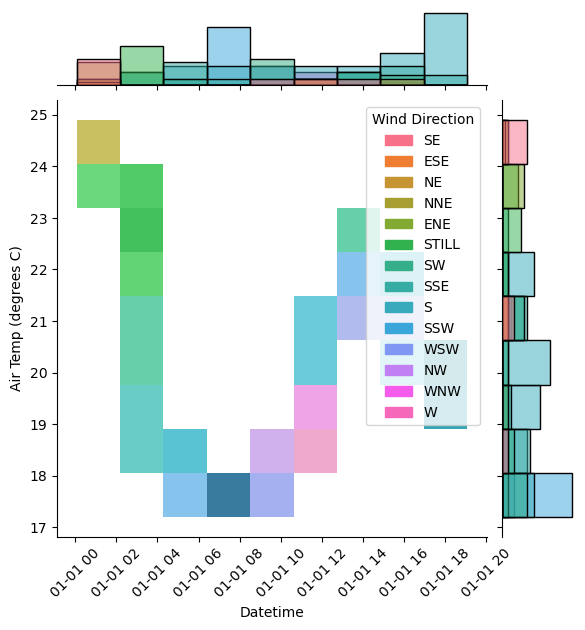

In [62]:
sns.jointplot(data=melb2, x="Datetime", y="Air Temp (degrees C)", hue="Wind Direction", kind="hist")
plt.xticks(rotation=45)

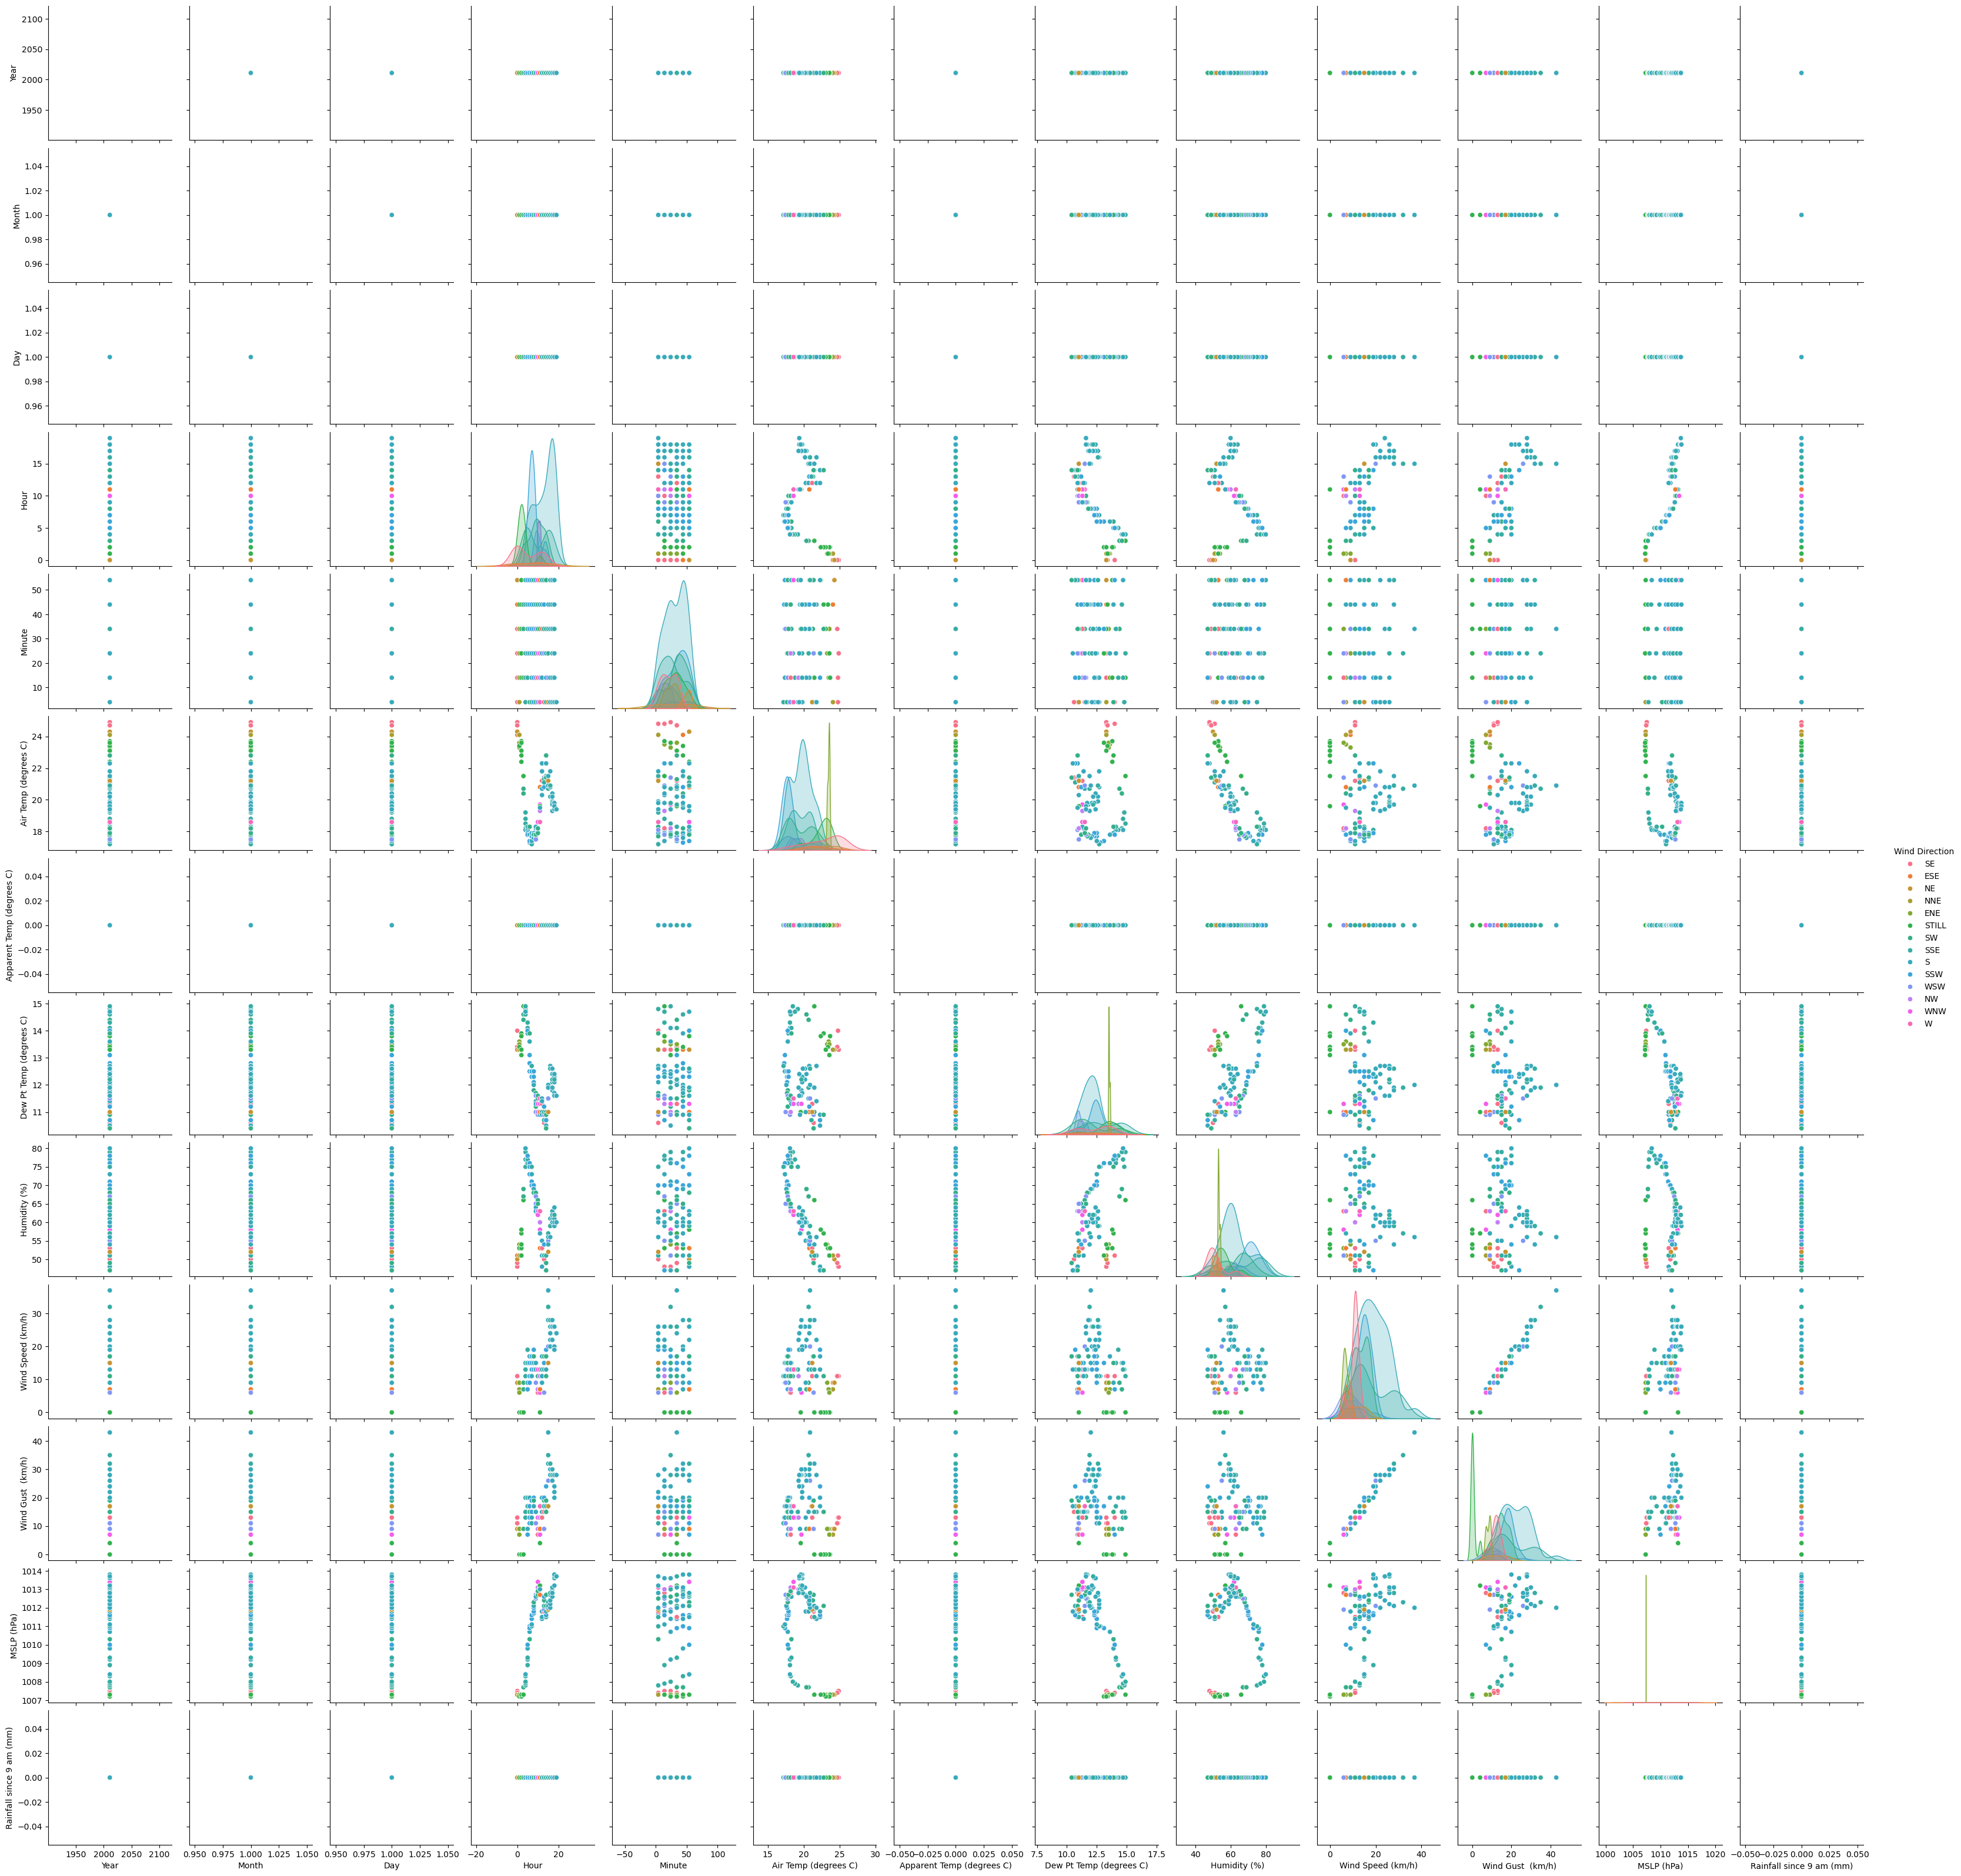

In [63]:
sns.pairplot(data=melb2, hue="Wind Direction")


In [64]:
melb3 = melb.iloc[::,5:]

In [65]:
melb3

,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...
1113146,33.4,32.5,14.9,32,NW,20.0,35.0,1014.6,0.0,2025-03-12 15:30:00
1113147,33.5,32.9,14.5,31,NNW,26.0,41.0,1014.6,0.0,2025-03-12 15:34:00
1113148,34.4,34.2,14.8,30,WNW,26.0,41.0,1014.4,0.0,2025-03-12 16:00:00
1113149,33.6,32.4,14.1,30,WNW,26.0,41.0,1014.1,0.0,2025-03-12 16:30:00


(array([  6971.,  84091., 319043., 346105., 215175.,  85262.,  36452.,
         14956.,   4182.,    914.]),
 array([ 0.5,  4.8,  9.1, 13.4, 17.7, 22. , 26.3, 30.6, 34.9, 39.2, 43.5]),
 <BarContainer object of 10 artists>)

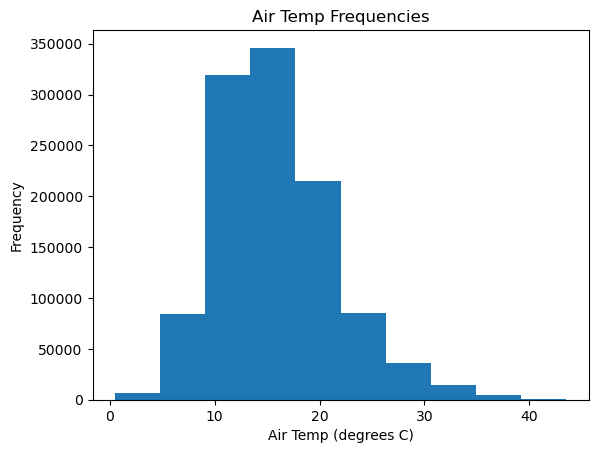

In [66]:
plt.title("Air Temp Frequencies")
plt.ylabel("Frequency")
plt.xlabel("Air Temp (degrees C)")
plt.hist(melb3["Air Temp (degrees C)"])

(array([1.068876e+06, 2.631700e+04, 9.426000e+03, 3.071000e+03,
        1.795000e+03, 1.214000e+03, 8.960000e+02, 5.490000e+02,
        4.240000e+02, 2.800000e+01]),
 array([ 0.  ,  5.46, 10.92, 16.38, 21.84, 27.3 , 32.76, 38.22, 43.68,
        49.14, 54.6 ]),
 <BarContainer object of 10 artists>)

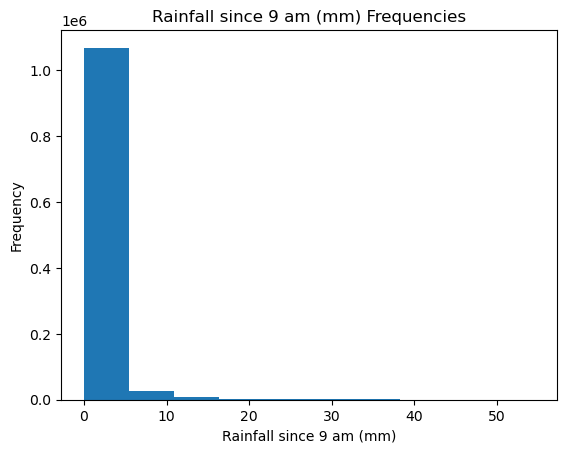

In [67]:
plt.title("Rainfall since 9 am (mm) Frequencies")
plt.ylabel("Frequency")
plt.xlabel("Rainfall since 9 am (mm)")
plt.hist(melb3["Rainfall since 9 am (mm)"])

In [68]:
melb.shape
air_month_av = melb.groupby(["Year", "Month"])["Air Temp (degrees C)"].mean().reset_index()


In [69]:
air_month_av = air_month_av.sort_values(["Year", "Month"])


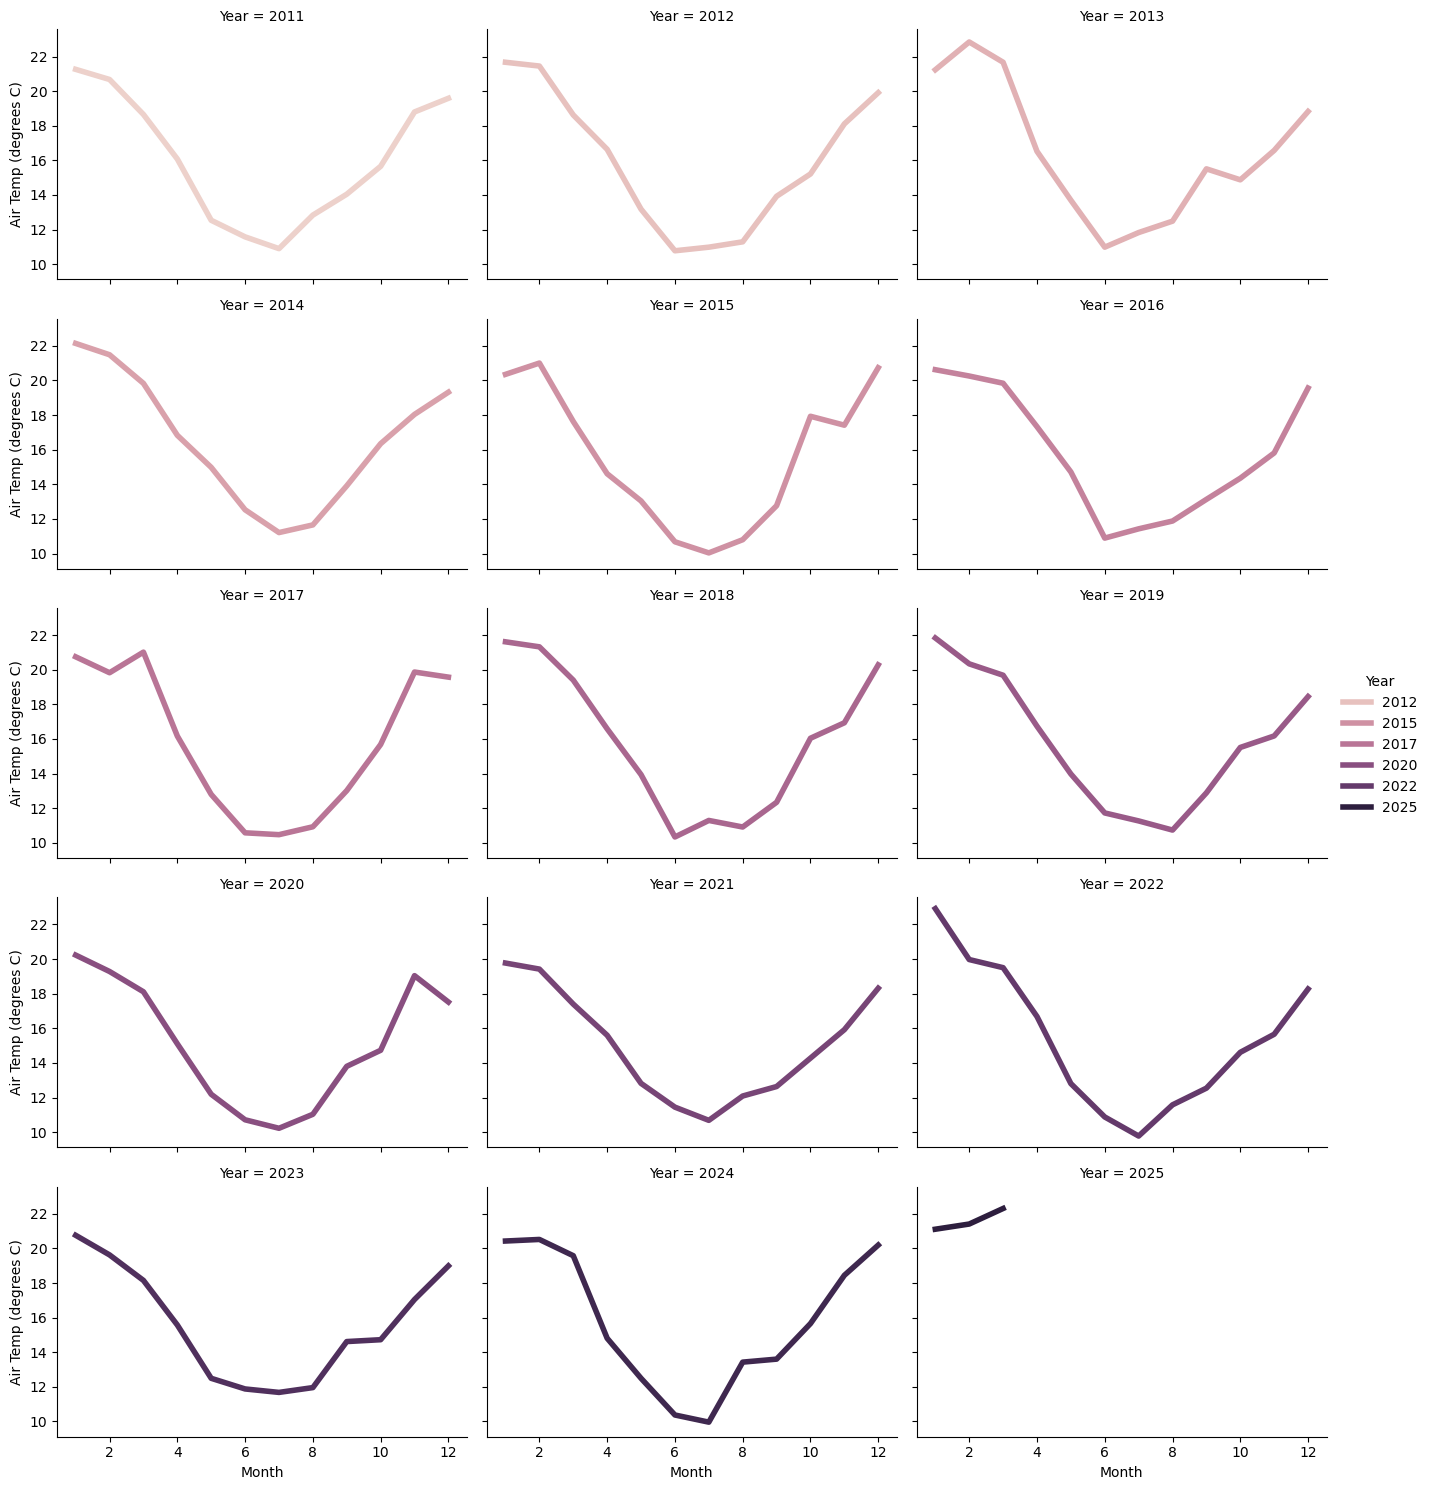

In [70]:
g1 = sns.relplot(
    data = air_month_av,
    x = "Month", y = "Air Temp (degrees C)", col = "Year",
    hue = "Year", kind = "line", linewidth = 4, zorder = 5,
    col_wrap = 3, height = 3, aspect=1.5, legend = True, 
)

### Average temperature by Month, from January 2011 to March 2025

The above line plots demonstrate that temperature is generally highest between December to February in Melbourne, with a mean temperature from 17 to 22 degrees C.

Between the months of May to September, mean temperatures are 16 degrees and lower. It demonstrates the expected Summer to Winter highs and lows.

In [71]:
melb

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113146,2025,3,12,15,30,33.4,32.5,14.9,32,NW,20.0,35.0,1014.6,0.0,2025-03-12 15:30:00
1113147,2025,3,12,15,34,33.5,32.9,14.5,31,NNW,26.0,41.0,1014.6,0.0,2025-03-12 15:34:00
1113148,2025,3,12,16,0,34.4,34.2,14.8,30,WNW,26.0,41.0,1014.4,0.0,2025-03-12 16:00:00
1113149,2025,3,12,16,30,33.6,32.4,14.1,30,WNW,26.0,41.0,1014.1,0.0,2025-03-12 16:30:00


In [72]:
melb_new = melb[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Air Temp (degrees C)', 'Humidity (%)', 'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Datetime']]

In [73]:
melb_new.loc[:,"Dew Pt Temp (degrees C)"] = melb_new.loc[:,'Air Temp (degrees C)'] - ((100-melb_new.loc[:,'Humidity (%)'])/5)

/tmp/ipykernel_139/1715486890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  melb_new.loc[:,"Dew Pt Temp (degrees C)"] = melb_new.loc[:,'Air Temp (degrees C)'] - ((100-melb_new.loc[:,'Humidity (%)'])/5)


In [74]:
# Apparent Temperature = actual temperature + 0.33(humidity) - 0.7(wind speed)  - 4

melb_new.loc[:,"Apparent Temp (degrees C)"] = melb_new.loc[:, "Air Temp (degrees C)"] + (0.33 * melb_new.loc[:, "Humidity (%)"]) - (0.7 * melb_new.loc[:, "Wind Speed (km/h)"]) - 4


# Some of the apparent temeratures feel suspciously high?

In [75]:
melb_new

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime,Dew Pt Temp (degrees C),Apparent Temp (degrees C)
0,2011,1,1,0,4,24.8,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00,15.0,29.93
1,2011,1,1,0,14,24.8,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00,14.4,28.94
2,2011,1,1,0,14,24.8,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00,14.4,28.94
3,2011,1,1,0,24,24.9,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00,14.5,29.04
4,2011,1,1,0,24,24.9,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00,14.5,29.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113146,2025,3,12,15,30,33.4,32,NW,20.0,35.0,1014.6,0.0,2025-03-12 15:30:00,19.8,25.96
1113147,2025,3,12,15,34,33.5,31,NNW,26.0,41.0,1014.6,0.0,2025-03-12 15:34:00,19.7,21.53
1113148,2025,3,12,16,0,34.4,30,WNW,26.0,41.0,1014.4,0.0,2025-03-12 16:00:00,20.4,22.10
1113149,2025,3,12,16,30,33.6,30,WNW,26.0,41.0,1014.1,0.0,2025-03-12 16:30:00,19.6,21.30


In [76]:
# What I have an issue with is that there are entries with duplicate times? Perhaps by making indiividual hourly and minutely groupbys this would be fixed?
# Things to be able to visualise
    # Create a new dataframe using the hot encoding for Wind Direction, creating a new binary column for each different direction, making a 0 or 1 entry if False or True.as_integer_ratio
minutely_stats = melb_new.groupby(["Year", "Month", "Day", "Hour", 'Minute'])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

hourly_stats = melb_new.groupby(["Year", "Month", "Day", "Hour"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()
daily_stats = melb_new.groupby(["Year", "Month", "Day"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

monthly_stats = melb_new.groupby(["Year", "Month"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)','Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

yearly_stats = melb_new.groupby(["Year"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)','Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()



In [77]:
monthly_stats

,Year,Month,Air Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Apparent Temp (degrees C),Dew Pt Temp (degrees C)
0,2011,1,21.258162,63.960259,17.206292,20.070650,1011.298662,1.159431,26.320643,14.050214
1,2011,2,20.672299,65.585321,16.275642,18.919617,1014.417444,0.705364,26.922506,13.789363
2,2011,3,18.651521,63.604020,17.407958,20.124742,1016.274005,0.570949,23.455277,11.372325
3,2011,4,16.077033,67.602410,16.572440,18.818675,1022.159307,1.184307,22.785120,9.597515
4,2011,5,12.537567,71.397640,16.211874,18.538848,1020.318439,1.143994,20.750477,6.817096
...,...,...,...,...,...,...,...,...,...,...
166,2024,11,18.444333,65.305117,17.773314,24.551411,1014.811286,1.017711,23.553702,11.505356
167,2024,12,20.192608,59.571685,19.004032,26.624552,1011.319892,0.556989,22.548441,12.106944
168,2025,1,21.107485,60.817571,19.177947,26.383236,1013.131466,1.749646,23.752721,13.271000
169,2025,2,21.406994,61.674603,20.412202,28.355159,1013.863492,0.804822,23.471071,13.741915


In [78]:
yearly_stats

,Year,Air Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Apparent Temp (degrees C),Dew Pt Temp (degrees C)
0,2011,15.920349,65.167461,18.602795,21.453019,1017.259746,0.984415,20.403655,8.953841
1,2012,15.967283,63.143651,20.135065,23.276793,1016.981842,0.833488,18.710142,8.596013
2,2013,16.295460,62.095503,20.161032,23.320915,1016.169621,0.810912,18.674254,8.714561
3,2014,16.514703,63.604433,19.343621,22.413451,1017.275966,0.625910,19.963632,9.235590
4,2015,14.488322,69.530201,19.526499,22.621029,1019.601114,0.584988,19.764739,8.394362
5,2016,15.801503,68.365570,19.859735,23.075048,1015.953625,0.831638,20.460326,9.474617
6,2017,15.869491,68.007843,18.773708,21.733852,1017.690330,0.767034,21.170201,9.471060
7,2018,15.922610,66.264964,19.602774,22.796492,1017.060282,0.772216,20.068107,9.175603
8,2019,15.794773,66.480776,19.854895,23.094381,1018.292272,0.521527,19.835002,9.090928
9,2020,15.118917,71.569892,18.840315,21.853639,1017.710671,0.943249,21.548761,9.432896


In [79]:
daily_stats

,Year,Month,Day,Air Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Apparent Temp (degrees C),Dew Pt Temp (degrees C)
0,2011,1,1,19.650787,61.574803,14.350394,16.582677,1011.803543,0.0,25.925197,11.965748
1,2011,1,2,18.175258,52.097938,21.891753,26.025773,1016.319072,0.0,16.043351,8.594845
2,2011,1,3,16.590734,47.814672,24.389961,28.575290,1016.943629,0.0,11.296602,6.153668
3,2011,1,4,16.800775,59.879845,15.709302,18.767442,1012.389922,0.0,21.564612,8.776744
4,2011,1,5,18.117188,66.585938,19.898438,23.125000,1010.092578,0.0,22.161641,11.434375
...,...,...,...,...,...,...,...,...,...,...,...
5178,2025,3,8,23.656944,56.666667,18.236111,24.652778,1018.729167,0.0,25.591667,14.990278
5179,2025,3,9,26.411111,48.152778,25.500000,34.291667,1016.425000,0.0,20.451528,16.041667
5180,2025,3,10,26.812500,53.680556,17.791667,24.944444,1017.040278,0.1,28.072917,17.548611
5181,2025,3,11,25.284722,62.166667,13.138889,17.805556,1018.973611,0.0,32.602500,17.718056


In [80]:
minutely_stats

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Apparent Temp (degrees C),Dew Pt Temp (degrees C)
0,2011,1,1,0,4,24.8,51.0,11.0,13.0,1007.4,0.0,29.93,15.0
1,2011,1,1,0,14,24.8,48.0,11.0,11.0,1007.5,0.0,28.94,14.4
2,2011,1,1,0,24,24.9,48.0,11.0,13.0,1007.5,0.0,29.04,14.5
3,2011,1,1,0,34,24.7,49.0,11.0,11.0,1007.4,0.0,29.17,14.5
4,2011,1,1,0,44,24.1,51.0,9.0,9.0,1007.3,0.0,30.63,14.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
568153,2025,3,12,15,5,32.8,33.0,20.0,35.0,1015.0,0.0,25.69,19.4
568154,2025,3,12,15,30,33.4,32.0,20.0,35.0,1014.6,0.0,25.96,19.8
568155,2025,3,12,15,34,33.5,31.0,26.0,41.0,1014.6,0.0,21.53,19.7
568156,2025,3,12,16,0,34.4,30.0,26.0,41.0,1014.4,0.0,22.10,20.4


In [81]:
# Need to think about how to manage duplicates with the Wind Direction column?
    # Perhaps I 

minutely_stats2 = melb_new.groupby(["Datetime"]).agg(air_temp = ("Air Temp (degrees C)", "mean"), hum = ("Humidity (%)", "mean"), wind_speed = ('Wind Speed (km/h)', 'mean'), wind_gust = ('Wind Gust  (km/h)', 'mean'),
       pre = ('MSLP (hPa)', 'mean'), rain = ('Rainfall since 9 am (mm)', 'mean'), app_temp = ('Apparent Temp (degrees C)', 'mean'), dew_temp = ('Dew Pt Temp (degrees C)', 'mean'), wind_di = ("Wind Direction", lambda x: None if len(x.mode()) == 0 else x.mode().iloc[0])).reset_index()

new_stats = melb_new.groupby(["Year", "Month", "Day", "Hour", 'Minute', "Datetime"]).agg(air_temp = ("Air Temp (degrees C)", "mean"), hum = ("Humidity (%)", "mean"), wind_speed = ('Wind Speed (km/h)', 'mean'), wind_gust = ('Wind Gust  (km/h)', 'mean'),
       pre = ('MSLP (hPa)', 'mean'), rain = ('Rainfall since 9 am (mm)', 'mean'), app_temp = ('Apparent Temp (degrees C)', 'mean'), dew_temp = ('Dew Pt Temp (degrees C)', 'mean'), wind_di = ("Wind Direction", lambda x: None if len(x.mode()) == 0 else x.mode().iloc[0])).reset_index()

In [82]:
new_stats

,Year,Month,Day,Hour,Minute,Datetime,air_temp,hum,wind_speed,wind_gust,pre,rain,app_temp,dew_temp,wind_di
0,2011,1,1,0,4,2011-01-01 00:04:00,24.8,51.0,11.0,13.0,1007.4,0.0,29.93,15.0,SE
1,2011,1,1,0,14,2011-01-01 00:14:00,24.8,48.0,11.0,11.0,1007.5,0.0,28.94,14.4,SE
2,2011,1,1,0,24,2011-01-01 00:24:00,24.9,48.0,11.0,13.0,1007.5,0.0,29.04,14.5,SE
3,2011,1,1,0,34,2011-01-01 00:34:00,24.7,49.0,11.0,11.0,1007.4,0.0,29.17,14.5,SE
4,2011,1,1,0,44,2011-01-01 00:44:00,24.1,51.0,9.0,9.0,1007.3,0.0,30.63,14.3,ESE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568153,2025,3,12,15,5,2025-03-12 15:05:00,32.8,33.0,20.0,35.0,1015.0,0.0,25.69,19.4,NW
568154,2025,3,12,15,30,2025-03-12 15:30:00,33.4,32.0,20.0,35.0,1014.6,0.0,25.96,19.8,NW
568155,2025,3,12,15,34,2025-03-12 15:34:00,33.5,31.0,26.0,41.0,1014.6,0.0,21.53,19.7,NNW
568156,2025,3,12,16,0,2025-03-12 16:00:00,34.4,30.0,26.0,41.0,1014.4,0.0,22.10,20.4,WNW


In [83]:
directionality_table = {'N': 0,
                        'NNE': 1,
                        'NE': 2,
                        'ENE': 3,
                        'E': 4,
                        'ESE': 5,
                        'SE': 6,
                        'SSE': 7,
                        'S': 8,
                        'SSW': 9,
                        'SW': 10,
                        'WSW': 11,
                        'W': 12,
                        'WNW': 13,
                        'NW': 14,
                        'NNW': 15,
                        'STILL': None
}

In [84]:
new_stats["Num Direction"] = new_stats["wind_di"].replace(directionality_table)
new_stats["Degree Direction"] = new_stats["Num Direction"] * 22.5
new_stats["Vector Direction"] = np.tan(new_stats["Degree Direction"]*180/np.pi)
new_stats["lat"] = -37.6707
new_stats['long'] = 144.8379 # (latitude, longitude)

/tmp/ipykernel_139/1352567584.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_stats["Num Direction"] = new_stats["wind_di"].replace(directionality_table)


In [85]:
new_stats

,Year,Month,Day,Hour,Minute,Datetime,air_temp,hum,wind_speed,wind_gust,pre,rain,app_temp,dew_temp,wind_di,Num Direction,Degree Direction,Vector Direction,lat,long
0,2011,1,1,0,4,2011-01-01 00:04:00,24.8,51.0,11.0,13.0,1007.4,0.0,29.93,15.0,SE,6.0,135.0,0.341543,-37.6707,144.8379
1,2011,1,1,0,14,2011-01-01 00:14:00,24.8,48.0,11.0,11.0,1007.5,0.0,28.94,14.4,SE,6.0,135.0,0.341543,-37.6707,144.8379
2,2011,1,1,0,24,2011-01-01 00:24:00,24.9,48.0,11.0,13.0,1007.5,0.0,29.04,14.5,SE,6.0,135.0,0.341543,-37.6707,144.8379
3,2011,1,1,0,34,2011-01-01 00:34:00,24.7,49.0,11.0,11.0,1007.4,0.0,29.17,14.5,SE,6.0,135.0,0.341543,-37.6707,144.8379
4,2011,1,1,0,44,2011-01-01 00:44:00,24.1,51.0,9.0,9.0,1007.3,0.0,30.63,14.3,ESE,5.0,112.5,-0.975369,-37.6707,144.8379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568153,2025,3,12,15,5,2025-03-12 15:05:00,32.8,33.0,20.0,35.0,1015.0,0.0,25.69,19.4,NW,14.0,315.0,-0.286741,-37.6707,144.8379
568154,2025,3,12,15,30,2025-03-12 15:30:00,33.4,32.0,20.0,35.0,1014.6,0.0,25.96,19.8,NW,14.0,315.0,-0.286741,-37.6707,144.8379
568155,2025,3,12,15,34,2025-03-12 15:34:00,33.5,31.0,26.0,41.0,1014.6,0.0,21.53,19.7,NNW,15.0,337.5,1.077754,-37.6707,144.8379
568156,2025,3,12,16,0,2025-03-12 16:00:00,34.4,30.0,26.0,41.0,1014.4,0.0,22.10,20.4,WNW,13.0,292.5,-5.213811,-37.6707,144.8379


In [86]:
# equation for the positional change after 30 mins
    # x' = 0.5 * s * (x cos(angle) + ysin(angle))
    # 
# plt.ylabel("Latitude")
# plt.xlabel("Longitude")
# plt.title("Wind Map (30 mins)")
# for i in range(new_stats.shape[0]):
#     x = [new_stats[i,"long"], 0.5 * new_stats['wind_speed'] *((new_stats[i,"long"] * np.cos(new_stats["Degree Direction"] * 180/np.pi) + (new_stats[i,"lat"] * np.sin(new_stats["Degree Direction"]))
#     plt.plot(, y = new_stats['lat'])


new_stats.describe()

,Year,Month,Day,Hour,Minute,Datetime,air_temp,hum,wind_speed,wind_gust,pre,rain,app_temp,dew_temp,Num Direction,Degree Direction,Vector Direction,lat,long
count,568158.000000,568158.000000,568158.000000,568158.000000,568158.000000,568158,568158.000000,568158.000000,568154.000000,568151.000000,568124.000000,567703.000000,568154.000000,568158.000000,551751.000000,551751.000000,551751.000000,5.681580e+05,5.681580e+05
mean,2016.798019,6.444676,15.747760,11.445050,25.369633,2017-04-17 02:45:07.572893184,15.874314,66.913984,19.284854,22.712614,1017.210828,0.792866,20.456516,9.257110,6.892852,155.089171,-2.612213,-3.767070e+01,1.448379e+02
min,2011.000000,1.000000,1.000000,0.000000,0.000000,2011-01-01 00:04:00,0.500000,0.000000,0.000000,0.000000,988.100000,0.000000,-37.510000,-5.300000,0.000000,0.000000,-40.093646,-3.767070e+01,1.448379e+02
25%,2014.000000,3.000000,8.000000,5.000000,10.000000,2014-02-21 04:17:30,11.900000,55.000000,11.000000,13.000000,1012.200000,0.000000,14.360000,6.000000,1.000000,22.500000,-0.696494,-3.767070e+01,1.448379e+02
50%,2017.000000,6.000000,16.000000,11.000000,25.000000,2017-03-08 21:35:00,15.200000,68.000000,17.000000,20.000000,1017.300000,0.000000,21.160000,8.700000,8.000000,180.000000,0.000000,-3.767070e+01,1.448379e+02
75%,2020.000000,9.000000,23.000000,17.000000,40.000000,2020-03-25 15:17:30,19.000000,80.000000,26.000000,30.000000,1022.400000,0.200000,27.400000,12.100000,11.000000,247.500000,0.773292,-3.767070e+01,1.448379e+02
max,2025.000000,12.000000,31.000000,23.000000,59.000000,2025-03-12 16:30:00,43.500000,100.000000,100.000000,109.000000,1041.900000,54.600000,65.900000,36.900000,15.000000,337.500000,7.115484,-3.767070e+01,1.448379e+02
std,3.721900,3.474836,8.808667,6.888629,17.295225,NaN,5.592821,17.711222,10.550551,12.757957,7.609164,2.975882,9.838468,4.309201,5.099431,114.737194,10.814961,9.467990e-11,1.011359e-09


## Does humidity affect rainfall, and does this relationship change over time?

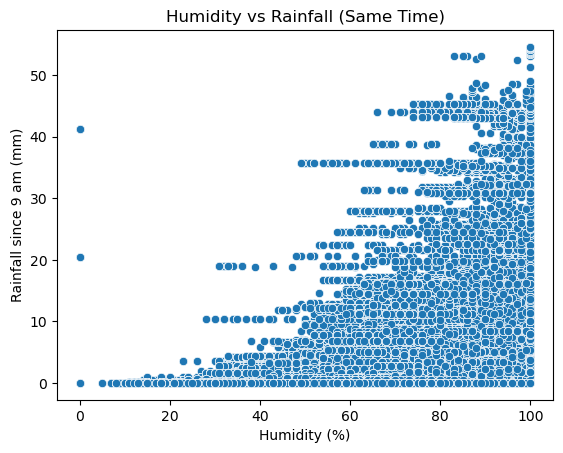

In [87]:
sns.scatterplot(
    data=melb,
    x="Humidity (%)",
    y="Rainfall since 9 am (mm)"
)

plt.title("Humidity vs Rainfall (Same Time)")
plt.show()

## Correlation analysis

In [88]:
melb[["Humidity (%)", "Rainfall since 9 am (mm)"]].corr()

,Humidity (%),Rainfall since 9 am (mm)
Humidity (%),1.000000,0.246961
Rainfall since 9 am (mm),0.246961,1.000000


## Binary rainfall

In [89]:
daily_stats["Rain_Tomorrow"] = (daily_stats["Rainfall since 9 am (mm)"].shift(-1) > 0).astype(int)

<Axes: xlabel='Rain_Tomorrow', ylabel='Humidity (%)'>

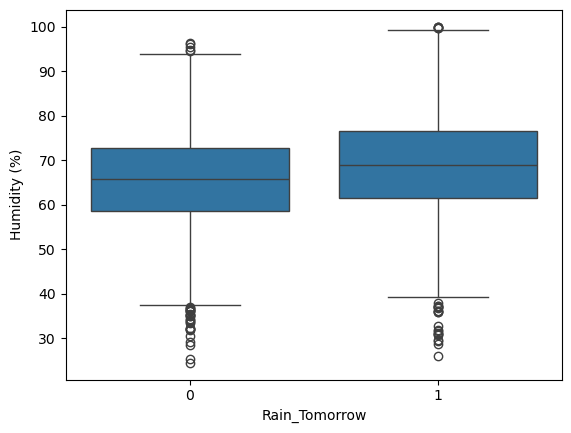

In [90]:
sns.boxplot(
    data=daily_stats,
    x="Rain_Tomorrow",
    y="Humidity (%)"
)

#### Higher humidity is associated with an increased likelihood of rainfall on the following day, although it is not a definitive predictor.

## Random Forest

In [108]:
# Random Forest - Binned Rainfall Classification

# 1. Copy and sort daily data
daily_rf = daily_stats.sort_values(["Year", "Month", "Day"]).copy()

# 2. Create lag features
daily_rf["Humidity_lag1"] = daily_rf["Humidity (%)"].shift(1)
daily_rf["AirTemp_lag1"] = daily_rf["Air Temp (degrees C)"].shift(1)
daily_rf["DewPoint_lag1"] = daily_rf["Dew Pt Temp (degrees C)"].shift(1)
daily_rf["WindSpeed_lag1"] = daily_rf["Wind Speed (km/h)"].shift(1)
daily_rf["WindGust_lag1"] = daily_rf["Wind Gust  (km/h)"].shift(1)
daily_rf["Pressure_lag1"] = daily_rf["MSLP (hPa)"].shift(1)
daily_rf["Rainfall_lag1"] = daily_rf["Rainfall since 9 am (mm)"].shift(1)
daily_rf["Month_feature"] = daily_rf["Month"]

# Create tomorrow's rainfall amount
daily_rf["Rainfall_Tomorrow"] = daily_rf["Rainfall since 9 am (mm)"].shift(-1)

# Bin tomorrow's rainfall
def rainfall_bin(rain):
    if rain == 0:
        return "no rain"
    elif rain <= 2.5:
        return "light rain"
    elif rain <= 10:
        return "moderate rain"
    else:
        return "heavy rain"

daily_rf["Rainfall_Bin_Tomorrow"] = daily_rf["Rainfall_Tomorrow"].apply(rainfall_bin)

# Choose features
features = [
    "Humidity_lag1",
    "AirTemp_lag1",
    "DewPoint_lag1",
    "WindSpeed_lag1",
    "WindGust_lag1",
    "Pressure_lag1",
    "Rainfall_lag1",
    "Month_feature"
]

# Remove missing rows AFTER creating all columns
daily_rf = daily_rf.dropna(subset=features + ["Rainfall_Bin_Tomorrow"]).reset_index(drop=True)

X = daily_rf[features]
y = daily_rf["Rainfall_Bin_Tomorrow"]

# Time-based split
split_index = int(len(daily_rf) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
# Predict and evaluate
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5814850530376084
               precision    recall  f1-score   support

   heavy rain       0.00      0.00      0.00        13
   light rain       0.60      0.56      0.58       444
moderate rain       0.13      0.07      0.09        95
      no rain       0.61      0.72      0.66       485

     accuracy                           0.58      1037
    macro avg       0.34      0.34      0.33      1037
 weighted avg       0.56      0.58      0.57      1037



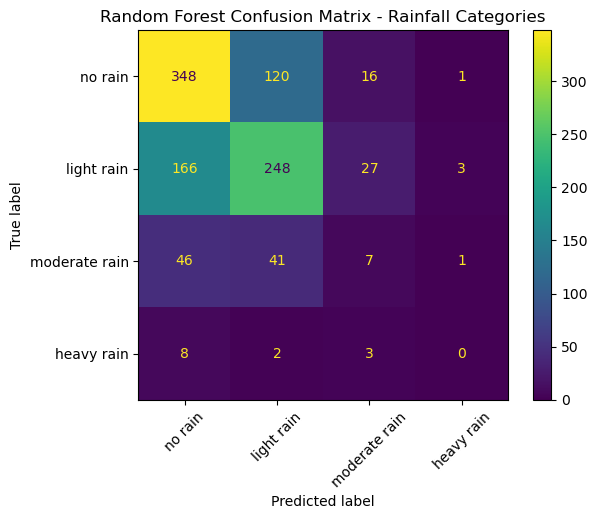

In [110]:
# Confusion matrix
labels = ["no rain", "light rain", "moderate rain", "heavy rain"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Random Forest Confusion Matrix - Rainfall Categories")
plt.xticks(rotation=45)
plt.show()

Makes sense since rainfall data is usually hella noisy, more factors that contribute to rainfall that was not provided in the dataset

Precision (Rain = 0.69)
When model predicts rain, it’s correct ~69% of the time
Recall (Rain = 0.62)
It only catches ~62% of actual rainy days.

Model is better at avoiding false rain predictions than catching all rain events

Correct rain predictions = 341
Correct no rain = 331
but missed rain (false negatives) = 210

The model correctly identifies a majority of both rain and non-rainy days, however it struggles with false negatives, missing approximately 210 rainfall events. This suggests the model is somewhat conservative in predicting rain.

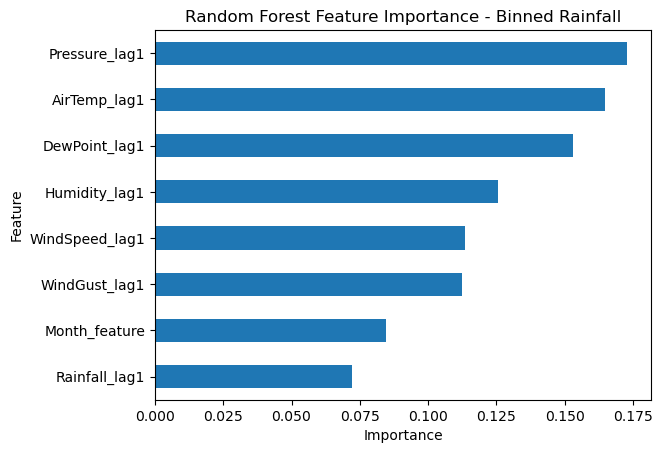

In [112]:
# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values()

importance.plot(kind="barh")
plt.title("Random Forest Feature Importance - Binned Rainfall")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Feature importance analysis shows that atmospheric pressure is the most influential predictor, followed by seasonal effects and temperature related variables. While humidity contributes to the model, it is less dominant, supporting earlier findings that humidity alone is not a strong predictor of rainfall.